# Exploring report.csv

Open this notebook with:

```bash
uv run --with jupyter --with pandas --with matplotlib jupyter notebook explore_report.ipynb
```

The CSV has two row types:
- **`file`** — one row per entity per cell (volumes, file sizes, instance counts)
- **`instance`** — one row per labelled object (metrics, distances, thumbnails)

In [1]:
import base64
import io
import math

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## Load

In [2]:
REPORT = "results_uv_html/report.csv"  # adjust path as needed

df = pd.read_csv(REPORT)

files = df[df.row_type == "file"].copy()
instances = df[df.row_type == "instance"].copy()

print(f"{len(df):,} rows total — {len(files)} file rows, {len(instances):,} instance rows")
print("cells   :", sorted(df.cell_id.dropna().unique()))
print("entities:", sorted(df.entity_name.unique()))

12,586 rows total — 11 file rows, 12,575 instance rows
cells   : ['cell1', 'cell2']
entities: ['er', 'granule', 'mito', 'nucleus', 'pm', 'source']


## Example 1 — All files of a specific cell with their volumes

In [3]:
CELL = "cell1"  # change to any cell_id

cell_files = (
    files[files.cell_id == CELL]
    .loc[:, ["entity_name", "entity_kind", "total_volume_um3", "instance_count", "file_size_bytes", "file_name"]]
    .sort_values("entity_kind")
)

display(cell_files)

,entity_name,entity_kind,total_volume_um3,instance_count,file_size_bytes,file_name
2,er,label,20.846038,1.0,1208483.0,2025-10-27_8bit_bin2_gauss0-5_1_contrast_ER_la...
4,granule,label,57.274606,6233.0,1968019.0,2025-10-27_8bit_bin2_gauss0-5_1_contrast_granu...
6238,mito,label,20.836169,105.0,911155.0,2025-10-27_8bit_bin2_gauss0-5_1_contrast_mito_...
6344,nucleus,label,116.610771,1.0,433458.0,2025-10-27_8bit_bin2_gauss0-5_1_contrast_nucle...
1,pm,mask,578.234760,NaN,827154.0,2025-10-27_8bit_bin2_gauss0-5_1_contrast_PM_ma...
0,source,source,NaN,NaN,133325315.0,2025-10-27_8bit_bin2_gauss0-5-alpha_cell_1_con...


## Example 2 — Volumes of all entities across cells

In [4]:
pivot = (
    files[files.entity_kind != "source"]
    .pivot_table(index="entity_name", columns="cell_id", values="total_volume_um3")
)

display(pivot.style.format("{:.1f}"))

cell_id,cell1,cell2
entity_name,,
er,20.8,20.8
granule,57.3,57.3
mito,20.8,nan
nucleus,116.6,116.6
pm,578.2,578.2


## Example 3 — Top N mitochondria sorted by branch count, with thumbnails

In [5]:
N = 12
ENTITY = "mito"  # change to any label entity

top = (
    instances[(instances.entity_name == ENTITY) & instances.branches.notna()]
    .sort_values("branches", ascending=False)
    .head(N)
    .reset_index(drop=True)
)

print(top[["cell_id", "label_id", "branches", "volume_um3", "sphericity"]].to_string())

   cell_id  label_id  branches  volume_um3  sphericity
0    cell1     147.0      74.0    1.304015    0.205025
1    cell1     125.0      61.0    2.221005    0.192424
2    cell1      96.0      56.0    0.942348    0.199553
3    cell1      58.0      44.0    0.564972    0.235975
4    cell1      73.0      37.0    0.812493    0.234272
5    cell1     168.0      35.0    0.839883    0.243936
6    cell1     241.0      33.0    0.881898    0.262879
7    cell1      75.0      30.0    0.262198    0.299808
8    cell1     355.0      23.0    0.555848    0.277554
9    cell1     267.0      22.0    0.635393    0.289047
10   cell1     363.0      20.0    0.368455    0.306707
11   cell1      59.0      20.0    0.186479    0.300398


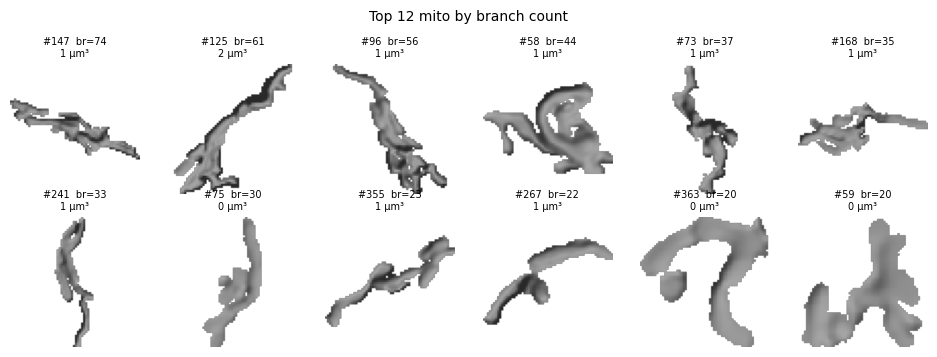

In [6]:
def decode_thumbnail(b64: str):
    return mpimg.imread(io.BytesIO(base64.b64decode(b64)))


cols = min(N, 6)
rows = math.ceil(N / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.8))
axes = [ax for row in (axes if rows > 1 else [axes]) for ax in (row if cols > 1 else [row])]

for i, (_, row) in enumerate(top.iterrows()):
    ax = axes[i]
    if pd.notna(row.get("thumbnail_b64")) and row.thumbnail_b64:
        ax.imshow(decode_thumbnail(row.thumbnail_b64))
    else:
        ax.set_facecolor("#f0f0f0")
    ax.set_title(
        f"#{int(row.label_id)}  br={int(row.branches)}\n{row.volume_um3:.0f} µm³",
        fontsize=7,
    )
    ax.axis("off")

for ax in axes[len(top):]:
    ax.set_visible(False)

fig.suptitle(f"Top {N} {ENTITY} by branch count", fontsize=10)
plt.tight_layout()
plt.show()

## Example 4 — Distance from granules to nucleus (per cell)

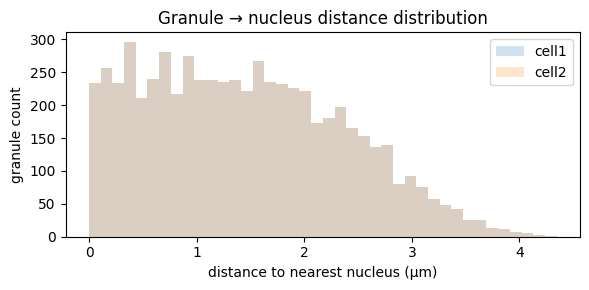

In [10]:
granules = instances[instances.entity_name == "granule"].copy()
dist_col = "distance_to_label_nucleus_um"

if dist_col not in granules.columns:
    print(f"Column {dist_col!r} not present — available distance columns:")
    print([c for c in granules.columns if c.startswith("distance_")])
else:
    fig, ax = plt.subplots(figsize=(6, 3))
    for cell, grp in granules.groupby("cell_id"):
        ax.hist(grp[dist_col].dropna(), bins=40, alpha=0.6, label=cell)
    ax.set_xlabel("distance to nearest nucleus (µm)")
    ax.set_ylabel("granule count")
    ax.legend()
    ax.set_title("Granule → nucleus distance distribution")
    plt.tight_layout()
    plt.show()